# Advanced EDA 01 — OLS Diagnostics
**Referencias:** Wooldridge (2010) *Introductory Econometrics*, Cap. 3–5 · Greene (2012) *Econometric Analysis*, Cap. 4–9

Antes de interpretar coeficientes OLS, hay que verificar los supuestos del modelo. Violarlos no siempre invalida la regresión, pero cambia qué conclusiones son válidas.

## Supuestos de Gauss-Markov (Wooldridge, Teorema 3.1)
Bajo MLR.1–MLR.5, OLS es BLUE (Best Linear Unbiased Estimator):

| Supuesto | Nombre | Consecuencia si se viola |
|---|---|---|
| MLR.1 | Linealidad en parámetros | Sesgo en estimación |
| MLR.2 | Muestra aleatoria | Inferencia inválida |
| MLR.3 | No colinealidad perfecta | OLS no computable |
| MLR.4 | Media condicional cero: $E(u|X)=0$ | Sesgo e inconsistencia |
| MLR.5 | Homocedasticidad: $Var(u|X)=\sigma^2$ | SE incorrectos → t/F inválidos |
| + MLR.6 | Normalidad de $u$ | Inferencia exacta en muestras pequeñas |

## Varianza de OLS (Greene, Ch. 4)
$$\text{Var}(\hat{\beta}) = \sigma^2 (X^\top X)^{-1}$$
Si hay heterocedasticidad ($Var(u_i|x_i) = \sigma_i^2$), esta fórmula es incorrecta → usar **HC standard errors** (Eicker-Huber-White, 1980).

In [1]:
import os
os.chdir('/Volumes/SSD_Gabo/proyectos/growth-analytics')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
import statsmodels.stats.api as sms
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan, het_white, acorr_breusch_godfrey
from statsmodels.stats.stattools import durbin_watson, jarque_bera

plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e8e8e8', 'axes.axisbelow': True,
    'axes.titlesize': 11, 'axes.titleweight': 'bold', 'legend.frameon': False,
    'font.family': 'Optima'
})
np.random.seed(42)

# Dataset: determinantes del salario (inspirado en Mincer 1974)
# ln(wage) = β0 + β1·educ + β2·exper + β3·exper² + β4·tenure + u
n = 800
educ   = np.random.randint(8, 20, n)                         # años de educación
exper  = np.clip(np.random.normal(15, 8, n), 0, 45).round(0) # experiencia laboral
tenure = np.clip(np.random.exponential(5, n), 0, 30).round(0)# años en empresa actual
female = np.random.binomial(1, 0.45, n)                      # género (brecha salarial)
urban  = np.random.binomial(1, 0.60, n)                      # área urbana

# Ecuación de Mincer con heterocedasticidad intencional
sigma_i = 0.2 + 0.05 * educ   # varianza crece con educación → heterocedasticidad
u       = np.random.normal(0, sigma_i, n)
log_wage = (1.2 + 0.10*educ + 0.04*exper - 0.0008*exper**2
            + 0.02*tenure - 0.18*female + 0.12*urban + u)
wage     = np.exp(log_wage)

df = pd.DataFrame({
    'log_wage': log_wage, 'wage': wage.round(2),
    'educ': educ, 'exper': exper, 'exper2': exper**2,
    'tenure': tenure, 'female': female, 'urban': urban,
})

# Estimar OLS
X_vars = ['educ', 'exper', 'exper2', 'tenure', 'female', 'urban']
X = sm.add_constant(df[X_vars])
y = df['log_wage']
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               log_wage   R-squared:                       0.180
Model:                            OLS   Adj. R-squared:                  0.173
Method:                 Least Squares   F-statistic:                     28.94
Date:                Sun, 28 Jun 2026   Prob (F-statistic):           2.08e-31
Time:                        19:11:03   Log-Likelihood:                -1041.8
No. Observations:                 800   AIC:                             2098.
Df Residuals:                     793   BIC:                             2130.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.0828      0.174      6.221      0.0

## 1 — Gráficas de diagnóstico de residuales (Wooldridge, Cap. 5)

/var/folders/3m/z0qp5nwj1vlccby390hqt0kc0000gn/T/ipykernel_17871/751838332.py:49: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Optima.
  plt.tight_layout()
/Volumes/SSD_Gabo/proyectos/growth-analytics/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Optima.
  fig.canvas.print_figure(bytes_io, **kw)


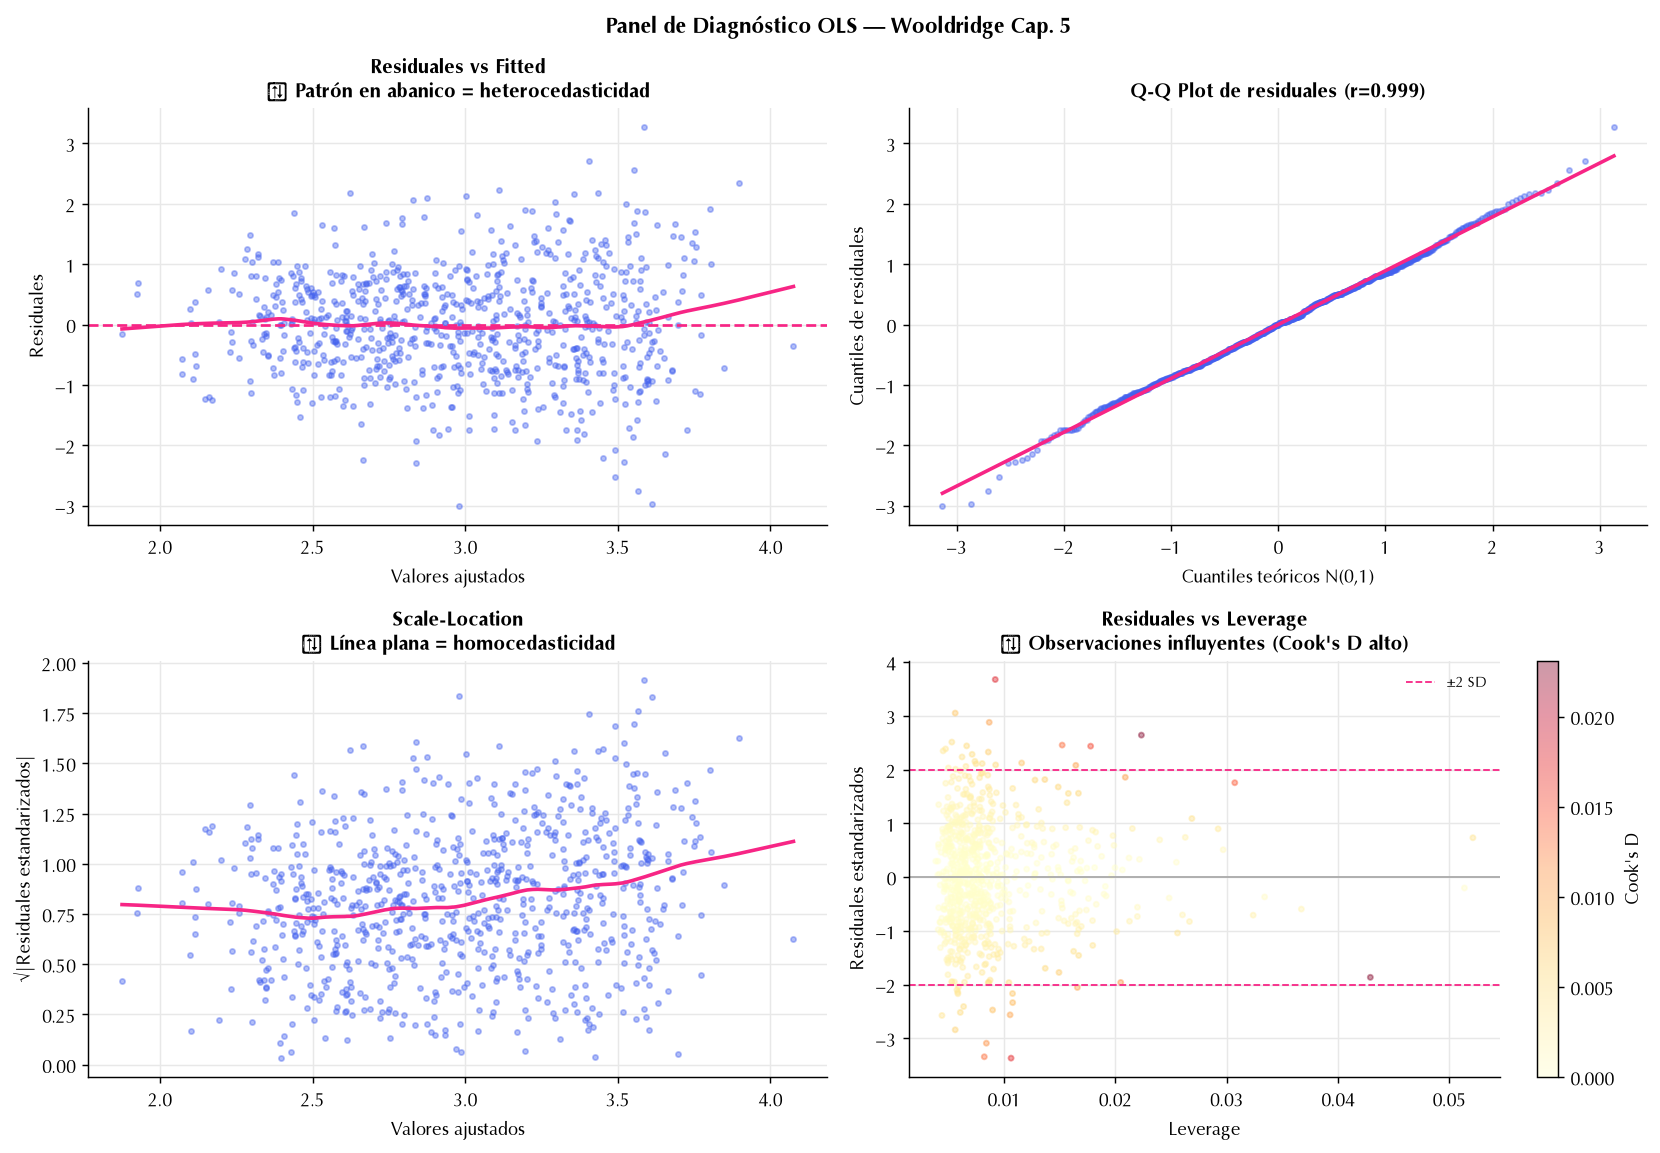

In [2]:
resid   = model.resid
fitted  = model.fittedvalues
std_res = resid / resid.std()

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# 1. Residuales vs Fitted — detecta no-linealidad y heterocedasticidad
axes[0,0].scatter(fitted, resid, s=8, alpha=0.4, color='#4361ee')
axes[0,0].axhline(0, color='#f72585', linewidth=1.5, linestyle='--')
# Línea LOWESS suavizada
lowess = sm.nonparametric.lowess(resid, fitted, frac=0.3)
axes[0,0].plot(lowess[:,0], lowess[:,1], color='#f72585', linewidth=2)
axes[0,0].set_xlabel('Valores ajustados')
axes[0,0].set_ylabel('Residuales')
axes[0,0].set_title('Residuales vs Fitted\n→ Patrón en abanico = heterocedasticidad')

# 2. Q-Q Plot — detecta no-normalidad
(osm, osr), (slope, intercept, r) = stats.probplot(resid, dist='norm')
axes[0,1].scatter(osm, osr, s=8, alpha=0.4, color='#4361ee')
axes[0,1].plot(osm, slope*np.array(osm)+intercept, color='#f72585', linewidth=2)
axes[0,1].set_xlabel('Cuantiles teóricos N(0,1)')
axes[0,1].set_ylabel('Cuantiles de residuales')
axes[0,1].set_title(f'Q-Q Plot de residuales (r={r:.3f})')

# 3. Scale-Location — √|residuales estandarizados| vs Fitted
axes[1,0].scatter(fitted, np.sqrt(np.abs(std_res)), s=8, alpha=0.4, color='#4361ee')
lowess2 = sm.nonparametric.lowess(np.sqrt(np.abs(std_res)), fitted, frac=0.3)
axes[1,0].plot(lowess2[:,0], lowess2[:,1], color='#f72585', linewidth=2)
axes[1,0].set_xlabel('Valores ajustados')
axes[1,0].set_ylabel('√|Residuales estandarizados|')
axes[1,0].set_title('Scale-Location\n→ Línea plana = homocedasticidad')

# 4. Residuales vs Leverage (Cook's distance)
influence = model.get_influence()
leverage  = influence.hat_matrix_diag
cooks_d   = influence.cooks_distance[0]
sc = axes[1,1].scatter(leverage, std_res, s=8, alpha=0.4,
                        c=cooks_d, cmap='YlOrRd', vmin=0, vmax=cooks_d.max())
axes[1,1].axhline(0,  color='#aaa', linewidth=1)
axes[1,1].axhline(2,  color='#f72585', linewidth=1, linestyle='--', label='±2 SD')
axes[1,1].axhline(-2, color='#f72585', linewidth=1, linestyle='--')
plt.colorbar(sc, ax=axes[1,1], label="Cook's D")
axes[1,1].set_xlabel('Leverage')
axes[1,1].set_ylabel('Residuales estandarizados')
axes[1,1].set_title("Residuales vs Leverage\n→ Observaciones influyentes (Cook's D alto)")
axes[1,1].legend(fontsize=8)

plt.suptitle('Panel de Diagnóstico OLS — Wooldridge Cap. 5', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 2 — Tests de Heterocedasticidad (Wooldridge, Cap. 8)

**Breusch-Pagan (1979)**: regresa $\hat{u}^2$ sobre $X$ y testea si los coeficientes son conjuntamente cero.
$$H_0: Var(u|X) = \sigma^2 \quad \text{(homocedasticidad)}$$

**White (1980)**: versión más general — incluye cuadrados e interacciones de $X$. Robusto a formas funcionales desconocidas de heterocedasticidad.

In [3]:
# Breusch-Pagan (1979)
bp_lm, bp_p, bp_f, bp_fp = het_breuschpagan(resid, model.model.exog)

# White (1980)
wh_lm, wh_p, wh_f, wh_fp = het_white(resid, model.model.exog)

print('Test de Heterocedasticidad')
print('─' * 55)
print(f'Breusch-Pagan (1979)   LM={bp_lm:.3f}  p={bp_p:.4f}  {"→ HETEROCED." if bp_p < 0.05 else "→ Homoced."}')
print(f'White (1980)           LM={wh_lm:.3f}  p={wh_p:.4f}  {"→ HETEROCED." if wh_p < 0.05 else "→ Homoced."}')
print()
print('Consecuencia: los SE de OLS son incorrectos.')
print('Solución 1: Errores estándar robustos (HC) — Eicker-Huber-White')
print('Solución 2: WLS (Weighted Least Squares) si se conoce la forma de Var(u|X)')

# Comparar SE clásicos vs HC robustos
model_hc = sm.OLS(y, X).fit(cov_type='HC3')   # HC3 = MacKinnon-White 1985

comparison = pd.DataFrame({
    'coef':    model.params.round(4),
    'SE_OLS':  model.bse.round(4),
    'SE_HC3':  model_hc.bse.round(4),
    'ratio':   (model_hc.bse / model.bse).round(3),
    'p_OLS':   model.pvalues.round(4),
    'p_HC3':   model_hc.pvalues.round(4),
})
print('\nComparación SE clásico vs HC3:')
print(comparison.to_string())
print('\nRatio > 1: SE clásico subestima la incertidumbre (frecuente con heterocedasticidad)')

Test de Heterocedasticidad
───────────────────────────────────────────────────────
Breusch-Pagan (1979)   LM=49.593  p=0.0000  → HETEROCED.
White (1980)           LM=64.063  p=0.0000  → HETEROCED.

Consecuencia: los SE de OLS son incorrectos.
Solución 1: Errores estándar robustos (HC) — Eicker-Huber-White
Solución 2: WLS (Weighted Least Squares) si se conoce la forma de Var(u|X)

Comparación SE clásico vs HC3:
          coef  SE_OLS  SE_HC3  ratio   p_OLS   p_HC3
const   1.0828  0.1741  0.1733  0.996  0.0000  0.0000
educ    0.1113  0.0090  0.0094  1.046  0.0000  0.0000
exper   0.0399  0.0126  0.0133  1.054  0.0016  0.0027
exper2 -0.0008  0.0004  0.0004  1.017  0.0227  0.0248
tenure  0.0167  0.0067  0.0066  0.996  0.0125  0.0119
female -0.1573  0.0636  0.0643  1.011  0.0137  0.0145
urban   0.0431  0.0644  0.0644  1.000  0.5036  0.5035

Ratio > 1: SE clásico subestima la incertidumbre (frecuente con heterocedasticidad)


## 3 — Test de Normalidad de Residuales: Jarque-Bera (1980)

$$JB = \frac{n}{6}\left(S^2 + \frac{(K-3)^2}{4}\right) \sim \chi^2(2)$$
donde $S$ = skewness y $K$ = kurtosis de los residuales.

> **Wooldridge (2010, p. 170):** La normalidad de $u$ es necesaria para inferencia exacta en muestras pequeñas. Con $n$ grande, el TCL garantiza que $\hat{\beta}$ es asintóticamente normal independientemente de la distribución de $u$.

In [ ]:
jb_stat, jb_p, jb_skew, jb_kurt = jarque_bera(resid)
_, sw_p = stats.shapiro(resid[:200])   # Shapiro-Wilk (máx ~5000 obs)
_, ks_p = stats.kstest(resid, lambda x: stats.norm.cdf(x, resid.mean(), resid.std()))

print('Tests de Normalidad de Residuales')
print('─' * 50)
print(f'Jarque-Bera (1980)  stat={jb_stat:.3f}  p={jb_p:.4f}  skew={jb_skew:.3f}  kurt={jb_kurt:.3f}')
print(f'Shapiro-Wilk        p={sw_p:.4f}  (submuestra n=200)')
print(f'Kolmogorov-Smirnov  p={ks_p:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(resid, bins=40, color='#4361ee', alpha=0.7, density=True)
x_norm = np.linspace(resid.min(), resid.max(), 200)
axes[0].plot(x_norm, stats.norm.pdf(x_norm, resid.mean(), resid.std()),
             color='#f72585', linewidth=2, label='N(μ,σ²)')
axes[0].set_title(f'Distribución de Residuales\nJB stat={jb_stat:.2f}  p={jb_p:.4f}')
axes[0].legend()

(osm, osr), (slope, intercept, r) = stats.probplot(resid, dist='norm')
axes[1].scatter(osm, osr, s=8, alpha=0.5, color='#4361ee')
axes[1].plot(osm, slope*np.array(osm)+intercept, color='#f72585', linewidth=2, label=f'r={r:.3f}')
axes[1].set_xlabel('Cuantiles N(0,1)'); axes[1].set_ylabel('Cuantiles residuales')
axes[1].set_title('Q-Q Normal')
axes[1].legend()

plt.tight_layout()
plt.show()

## 4 — Multicolinealidad: VIF (Wooldridge, Cap. 3)

$$VIF_j = \frac{1}{1 - R^2_j}$$
donde $R^2_j$ es el $R^2$ de regresar $x_j$ sobre las demás variables. VIF alto → $x_j$ es casi una combinación lineal del resto → SE inflados.

> **Regla de pulgar (Greene 2012, p. 76):** VIF > 10 es problemático. VIF > 5 merece atención.

In [ ]:
vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data['flag'] = vif_data['VIF'].apply(lambda v: '🔴 Problema' if v > 10 else '🟡 Atención' if v > 5 else '✓')
print(vif_data.round(2).to_string(index=False))

# Visualizar
fig, ax = plt.subplots(figsize=(8, 4))
vif_plot = vif_data[vif_data['feature'] != 'const'].copy()
colors = ['#f72585' if v > 10 else '#ff9f1c' if v > 5 else '#4361ee' for v in vif_plot['VIF']]
ax.barh(vif_plot['feature'], vif_plot['VIF'], color=colors, alpha=0.85)
ax.axvline(5,  color='#ff9f1c', linestyle='--', linewidth=1.5, label='VIF=5')
ax.axvline(10, color='#f72585', linestyle='--', linewidth=1.5, label='VIF=10')
ax.set_xlabel('VIF')
ax.set_title('Variance Inflation Factor — Wooldridge Cap. 3')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print('\nexper y exper² tienen VIF alto por construcción (son la misma variable).')
print('Solución: centrar la variable → exper_c = exper - mean(exper) antes de elevar al cuadrado.')

## 5 — Autocorrelación de Residuales (Wooldridge, Cap. 12)

En datos de corte transversal la autocorrelación suele no ser un problema. En datos de panel o series de tiempo es crítica.

**Durbin-Watson (1950-51):** $d = \frac{\sum_{t=2}^T(\hat{u}_t - \hat{u}_{t-1})^2}{\sum_{t=1}^T \hat{u}_t^2} \approx 2(1-\hat{\rho})$
- $d \approx 2$: sin autocorrelación
- $d < 2$: autocorrelación positiva
- $d > 2$: autocorrelación negativa

**Breusch-Godfrey (1978):** más general, permite autocorrelación de orden $p$.

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

dw = durbin_watson(resid)
bg_lm, bg_p, bg_f, bg_fp = acorr_breusch_godfrey(model, nlags=4)

print('Tests de Autocorrelación de Residuales')
print('─' * 50)
print(f'Durbin-Watson (1950)         d={dw:.4f}  {"→ Sin autocorr. (d≈2)" if 1.5 < dw < 2.5 else "→ Autocorr. detectada"}')
print(f'Breusch-Godfrey (1978) p={4} LM={bg_lm:.3f}  p={bg_p:.4f}  {"→ Autocorr." if bg_p < 0.05 else "→ Sin autocorr."}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(resid,  lags=20, ax=axes[0], color='#4361ee', title='ACF de Residuales OLS')
plot_pacf(resid, lags=20, ax=axes[1], color='#f72585', title='PACF de Residuales OLS')
plt.tight_layout()
plt.show()
print('Barras dentro de las bandas azules → no hay autocorrelación significativa en ese lag.')

## 6 — Leverage, Cook's Distance e Influential Observations

**Cook's Distance (1977):** mide cuánto cambian todos los $\hat{\beta}$ si se elimina la observación $i$.
$$D_i = \frac{(\hat{\beta} - \hat{\beta}_{(-i)})^\top (X^\top X) (\hat{\beta} - \hat{\beta}_{(-i)})}{p \cdot s^2}$$
> Regla de pulgar: $D_i > 4/n$ merece inspección (Belsley, Kuh & Welsch, 1980).

In [ ]:
influence   = model.get_influence()
cooks_d     = influence.cooks_distance[0]
leverage    = influence.hat_matrix_diag
dfbetas     = influence.dfbetas
threshold   = 4 / n

influential = np.where(cooks_d > threshold)[0]
print(f"Observaciones influyentes (Cook's D > 4/n = {threshold:.4f}): {len(influential)}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Cook's Distance
axes[0].stem(range(n), cooks_d, linefmt='#4361ee', markerfmt='o', basefmt='k-')
axes[0].axhline(threshold, color='#f72585', linestyle='--', linewidth=1.5,
                label=f'Umbral = 4/n = {threshold:.4f}')
axes[0].set_xlabel('Observación')
axes[0].set_ylabel("Cook's Distance")
axes[0].set_title("Cook's Distance — Belsley, Kuh & Welsch (1980)")
axes[0].legend(fontsize=8)

# Leverage vs Cook's D
axes[1].scatter(leverage, cooks_d, s=10, alpha=0.5, color='#4361ee')
axes[1].scatter(leverage[influential], cooks_d[influential], s=40, color='#f72585',
                zorder=5, label=f'Influyentes ({len(influential)})')
axes[1].axhline(threshold, color='#f72585', linestyle='--', linewidth=1)
axes[1].set_xlabel('Leverage ($h_{ii}$)')
axes[1].set_ylabel("Cook's Distance")
axes[1].set_title('Leverage vs Influencia')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f'\nDistribución de leverage: mean={leverage.mean():.4f}  max={leverage.max():.4f}')
print(f'Leverage promedio esperado: p/n = {X.shape[1]}/{n} = {X.shape[1]/n:.4f}')

## Resumen — Decisión ante cada problema

| Problema | Test | Solución |
|---|---|---|
| Heterocedasticidad | Breusch-Pagan, White | SE robustos HC3 o WLS |
| No-normalidad | Jarque-Bera, Shapiro-Wilk | Con n grande: TCL. Con n pequeño: bootstrapping |
| Multicolinealidad | VIF | Eliminar variable, ridge regression, centrar |
| Autocorrelación | Durbin-Watson, Breusch-Godfrey | SE robustos HAC (Newey-West 1987) |
| Obs. influyentes | Cook's D, DFBETAS | Investigar causa, modelos robustos |

**Referencias:**
- Wooldridge, J.M. (2010). *Introductory Econometrics: A Modern Approach* (4th ed.). South-Western.
- Greene, W.H. (2012). *Econometric Analysis* (7th ed.). Pearson.
- White, H. (1980). A heteroskedasticity-consistent covariance matrix estimator. *Econometrica*, 48(4).
- Breusch, T.S. & Pagan, A.R. (1979). A simple test for heteroscedasticity. *Econometrica*, 47(5).
- Jarque, C.M. & Bera, A.K. (1980). Efficient tests for normality. *Economics Letters*, 6(3).
- Cook, R.D. (1977). Detection of influential observations in linear regression. *Technometrics*, 19(1).

**Siguiente:** `02_stationarity_cointegration.ipynb`